# Setup & Configuration

**DataSpell/uv:** Use interpreter **uv (QC1)** on the status bar. Skip the pip cell below when using uv.

## SSL Certificate Fix (macOS)
Run the next cell only if you need to install/repair packages (e.g. not using uv). It can take a long time.


In [ ]:
# Skip this cell when using uv (deps are in .venv).
# SSL CERTIFICATE FIX (macOS)
# If you see SSL errors, run this first:
import subprocess
import sys
import ssl
try:
    # Try to fix SSL certificates on macOS
    cert_path = ssl.get_default_verify_paths().openssl_cafile
    print(f"SSL cert location: {cert_path}")
except Exception as e:
    print(f"SSL check: {e}")

# 1. Uninstall the conflicting/deprecated versions first
%pip uninstall -y qiskit qiskit-iqm iqm-client qiskit-machine-learning qiskit-aer

# 2. Install the 2026-supported stack:
#    - qiskit 2.x (latest stable)

#    - qiskit-aer 0.15.x (Qiskit 2.x compatible simulator)
#    - qiskit-machine-learning 0.9.x (Qiskit 2.0 compatibility release)
#    - iqm-client[qiskit] 33.x (includes built-in Qiskit adapter, replaces deprecated qiskit-iqm)
# Note: --trusted-host flags bypass SSL verification as a workaround
%pip install --trusted-host pypi.org --trusted-host files.pythonhosted.org \
             "qiskit>=2.0,<3.0" \
             "qiskit-aer>=0.15.0" \
             "qiskit-machine-learning>=0.9,<0.10" \
             "qiskit-algorithms==0.4.0" \
             "iqm-client[qiskit]>=33.0,<34.0"

print("✅ Installation complete.")

## Required Imports
**Run Part 1 first** (fast). Then run **Part 2** once (PyTorch + Qiskit ML; first time ~1–2 min). IQM loads only when you connect to the backend.

In [3]:
# Part 1: Fast imports (no PyTorch / Qiskit ML). Run this first.
import sys
import time
import subprocess
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score
import matplotlib.pyplot as plt

**Part 2: PyTorch + Qiskit ML** — Run the cell below once. First time can take 1–2 min; then continue with the rest of the notebook.

In [12]:
import torch
import torch.nn as nn
from ucimlrepo import fetch_ucirepo
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorEstimator, PrimitiveResult, PubResult
from qiskit.primitives.base import BaseEstimatorV2
from qiskit.primitives.containers.data_bin import DataBin
from qiskit.quantum_info import SparsePauliOp
import pandas as pd

In [5]:
# Part 2: Heavy imports (PyTorch, Qiskit ML). First run ~1–2 min.
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_algorithms.gradients import ReverseEstimatorGradient

---
# Circuit Definitions

## Hardware-Efficient Ansatz
Custom quantum circuit designed for IQM's star topology (5 qubits, QB3 as central hub).

In [6]:
def ansatz(n_qubits, depth):
    """
    Ansatz with Ring topology.
    Uses exclusively native-like gates: Rx, Ry, Rz, and Cz.
    No Hadamard or CX gates are used.
    """
    # For each full iteration (2 layers):
    # Layer 1: n_qubits (Ry) + n_qubits (Rz before Cz)
    # Layer 2: n_qubits (Rx) + n_qubits (Ry before Cz)
    # Total: 4 * n_qubits per iteration (depth // 2 iterations)
    params_per_iter = 4 * n_qubits
    theta = ParameterVector('θ', params_per_iter * (depth // 2))

    qc = QuantumCircuit(n_qubits)

    for j in range(depth // 2):
        offset = j * params_per_iter

        # -------- Layer 1: Ry + Ring Cz (with Rz) --------

        # 1. Independent Ry rotations
        for i in range(n_qubits):
            qc.ry(theta[offset + i], i)

        # 2. Ring entanglement (0-1, 1-2, ..., n-1-0)
        # Each pair: Rz on target + Cz
        for i in range(n_qubits):
            control = i
            target = (i + 1) % n_qubits

            param_idx = offset + n_qubits + i
            qc.rz(theta[param_idx], target)
            qc.cz(control, target)

        # -------- Layer 2: Rx + Ring Cz (with Ry) --------

        offset_l2 = offset + 2 * n_qubits

        # 1. Independent Rx rotations
        for i in range(n_qubits):
            qc.rx(theta[offset_l2 + i], i)

        # 2. Reverse ring entanglement (or shifted)
        # Each pair: Ry on target + Cz
        for i in range(n_qubits):
            control = i
            target = (i - 1) % n_qubits

            param_idx = offset_l2 + n_qubits + i
            qc.ry(theta[param_idx], target)
            qc.cz(control, target)

    return qc

## IQM Backend Estimator
Custom estimator class that interfaces with IQM quantum hardware and tracks detailed timing information. **Circuits are sent in batches** (one job per batch of samples, like the Garnet port flow)—so e.g. 50 samples use 1 job instead of 50.

<details>
<summary>📊 Timing Metrics Captured</summary>

- **QPU Execution Time**: Actual quantum circuit execution
- **Compilation Time**: Circuit transpilation and optimization  
- **Queue Time**: Waiting for QPU availability
- **Network Time**: Job upload and result download
- **Total Job Time**: End-to-end execution

</details>

In [7]:
class SimpleIQMJob:
    """A dummy job that simply holds the result."""
    def __init__(self, result):
        self._result = result

    def result(self):
        return self._result

# --- THE BRIDGE CLASS ---
class IQMBackendEstimator(BaseEstimatorV2):
    def __init__(self, backend, options=None):
        super().__init__()
        self._backend = backend
        self._options = options or {"shots": 100}
        # collecting timestamps
        self.timestamp_history = []
        self.total_qpu_time = 0.0  # Sum of time on quantum

    def _extract_timestamps(self, result):
        try:
            timeline = result._metadata.get('timeline', [])
            if not timeline:
                return None

            timestamps = {}
            for entry in timeline:
                timestamps[entry.status] = entry.timestamp

            return timestamps
        except Exception:
            return None

    def _counts_to_expectation(self, counts):
        """Convert single-circuit counts dict to ⟨Z⟩ expectation (p0 - p1) for measured qubit."""
        if isinstance(counts, list):
            counts = counts[0]
        shots = sum(counts.values())
        count_0 = sum(c for bs, c in counts.items() if bs[-1] == '0')
        p0 = count_0 / shots if shots else 0
        return p0 - (1 - p0)

    def run(self, pubs, precision=None):
        if not isinstance(pubs, list): pubs = [pubs]
        job_results = []
        shots_opt = self._options["shots"]
        max_circuits = self._options.get("max_circuits_per_job")  # None = no limit, one job per pub

        # 1. Prepare and transpile base circuit (same for all pubs in typical use)
        base_circuit = pubs[0][0]
        circuit_with_meas = base_circuit.copy()
        if circuit_with_meas.num_clbits == 0:
            circuit_with_meas.measure_all()
        transpiled_qc = transpile(circuit_with_meas, self._backend, optimization_level=3)

        for pub in pubs:
            _, observables, parameter_values = pub
            if parameter_values.ndim == 1:
                parameter_values = [parameter_values]

            # 2. Build list of bound circuits for this pub (batch)
            bound_circuits = [
                transpiled_qc.assign_parameters(params)
                for params in parameter_values
            ]
            n_circuits = len(bound_circuits)

            # 3. Execute in one or more batched jobs (IQM backend accepts list of circuits)
            pub_expectations = []
            for start in range(0, n_circuits, max_circuits or n_circuits):
                end = min(start + (max_circuits or n_circuits), n_circuits)
                batch = bound_circuits[start:end]
                try:
                    job = self._backend.run(batch, shots=shots_opt)
                    result = job.result()
                    # ========== TIMESTAMPS (one per batch job) ==========
                    ts = self._extract_timestamps(result)
                    if ts:
                        exec_start = ts.get('execution_started')
                        exec_end = ts.get('execution_ended')
                        comp_start = ts.get('compilation_started')
                        comp_end = ts.get('compilation_ended')
                        job_created = ts.get('created')
                        job_completed = ts.get('completed')
                        if exec_start and exec_end:
                            execution_time = (exec_end - exec_start).total_seconds()
                            compile_time = (comp_end - comp_start).total_seconds() if comp_start and comp_end else 0
                            job_time = (job_completed - job_created).total_seconds() if job_created and job_completed else 0
                            self.timestamp_history.append({
                                'execution_time_qpu': execution_time,
                                'job_time_total': job_time,
                                'compile_time': compile_time,
                                'raw_timestamps': ts,
                                'n_circuits': len(batch),
                            })
                            self.total_qpu_time += execution_time
                            print(f"Batch of {len(batch)} circuits | QPU: {execution_time*1000:.0f}ms | "
                                  f"Compile: {compile_time*1000:.0f}ms | Job: {job_time:.3f}s")
                    # =========================================================
                    counts_list = result.get_counts()
                    if not isinstance(counts_list, list):
                        counts_list = [counts_list]
                    for counts in counts_list:
                        pub_expectations.append(self._counts_to_expectation(counts))
                except Exception as e:
                    print(f"Batch job failed: {e}")
                    pub_expectations.extend([0.0] * len(batch))

            data = DataBin(evs=np.array(pub_expectations), shape=(len(pub_expectations),))
            job_results.append(PubResult(data=data))

        return SimpleIQMJob(PrimitiveResult(job_results))

    def print_timing_summary(self):
        """Detailed summary."""
        if not self.timestamp_history:
            print("Brak danych o timestampach.")
            return

        print("\n" + "="*60)
        print("DETAILED SUMMARY OF THE TIMESTAMPS")
        print("="*60)
        n_batches = len(self.timestamp_history)
        n_circuits = sum(t.get('n_circuits', 1) for t in self.timestamp_history)
        print(f"Number of batch jobs: {n_batches}  (total circuits: {n_circuits})")

        qpu_times = []
        compile_times = []
        queue_times = []
        network_times = []

        for t in self.timestamp_history:
            ts = t['raw_timestamps']

            # QPU
            if ts.get('execution_started') and ts.get('execution_ended'):
                qpu_times.append((ts['execution_ended'] - ts['execution_started']).total_seconds())

            # Compilation
            if ts.get('compilation_started') and ts.get('compilation_ended'):
                compile_times.append((ts['compilation_ended'] - ts['compilation_started']).total_seconds())

            # Queue (waiting for QPU)
            if ts.get('pending_execution') and ts.get('execution_started'):
                queue_times.append((ts['execution_started'] - ts['pending_execution']).total_seconds())

            # (created->received + ready->completed)
            net_time = 0
            if ts.get('created') and ts.get('received'):
                net_time += (ts['received'] - ts['created']).total_seconds()
            if ts.get('ready') and ts.get('completed'):
                net_time += (ts['completed'] - ts['ready']).total_seconds()
            network_times.append(net_time)

        print(f"\nTIME ON QPU :     {sum(qpu_times)*1000:8.2f} ms  (mean: {np.mean(qpu_times)*1000:.2f} ms/job)")
        print(f"Compilation :           {sum(compile_times)*1000:8.2f} ms  (mean: {np.mean(compile_times)*1000:.2f} ms/job)")
        print(f"Queue (wait QPU) :   {sum(queue_times)*1000:8.2f} ms  (mean: {np.mean(queue_times)*1000:.2f} ms/job)")
        print(f"(upload+down) :   {sum(network_times)*1000:8.2f} ms  (mean: {np.mean(network_times)*1000:.2f} ms/job)")

        total_measured = sum(qpu_times) + sum(compile_times) + sum(queue_times) + sum(network_times)
        total_job = sum(t['job_time_total'] for t in self.timestamp_history)
        other = total_job - total_measured

        print(f"Others (validation etc): {other*1000:8.2f} ms")
        print(f"\nTIME OVERALL:       {total_job*1000:8.2f} ms ({total_job:.3f} s)")

        print("\n" + "-"*40)
        print("PERCENTAGE DISTRIBUTION: ")
        print(f"  QPU:        {100*sum(qpu_times)/total_job:5.1f}%")
        print(f"  Compilation: {100*sum(compile_times)/total_job:5.1f}%")
        print(f"  Queue:    {100*sum(queue_times)/total_job:5.1f}%")
        print(f"  Network:       {100*sum(network_times)/total_job:5.1f}%")
        print(f"  Others:       {100*other/total_job:5.1f}%")
        print("="*60 + "\n")

## Hybrid Quantum-Classical Model
PyTorch-based model that integrates quantum circuits with classical neural networks.

In [8]:
"""
    The code below constructs the class HybridModel. It is built using the Qiskit and Pytorch library and
    and utilizes its built-in tools, to create a model connecting classical and quantum computing.

"""

class HybridModel(nn.Module):
    def __init__(self, ansatz_circuit, num_qubits):
        super().__init__()
        self.feature_map = self.angle_encoding(num_qubits)

        # Connecting the quantum circuit. Connecting our feature map (data) and ansatz
        self.qc = QuantumCircuit(num_qubits)
        self.qc.compose(self.feature_map, qubits=range(num_qubits), inplace=True)
        self.qc.compose(ansatz_circuit, inplace=True)

        # Firstly, we inicialize parameters. Our quantum model cannot tell whether the number came from ansatz or feature.
        # That is why here we sort them into two lists. If the number came from feature_map, then it will be a feature and the other way around.
        input_params = list(self.feature_map.parameters)
        weight_params = list(ansatz_circuit.parameters)

        '''
        Measure the Z-operator (spin) on the very first qubit (q_0) and ignore all the other qubits.
        Qiskit reads the string in a reversed order, that is why the Z gate is on the end.
        SparsePauliOp.from_list([("I" * (num_qubits - 1) + "Z", 1)]) converts string into a mathematical matrix that Qiskit can use for calculations
        Coefficient = 1 is a weight we multiply our result by. In QML it is mostly set to 1
        '''

        observable = SparsePauliOp.from_list([("I" * (num_qubits - 1) + "Z", 1)])

        # Estimator takes ansatz, observables and parameters (data and weights), returns the Expectation value.
        # !!!! CHANGE WHEN USING ON QUANTUM COMPUTER
        # Needed when running quantum simulations, it should be changed when implementing on real quantum computer
        estimator = StatevectorEstimator(seed=RANDOM_SEED)

        # Compute the gradients of the sampling probability by Adjoint Differentiation.
        gradient = ReverseEstimatorGradient(estimator)




        '''
        The EstimatorQNN
        This class from Qiskit Machine Learning is used to instantiate the quantum neural network.
        It leverages the Qiskit Primitives (Estimator) to efficiently calculate expectation values
        of the quantum circuit. This allows the model to output continuous, differentiable values (gradients)
        required for backpropagation in hybrid quantum-classical training.
        '''

        self.qnn = EstimatorQNN(
            circuit=self.qc,
            observables=observable,
            input_params=input_params,
            weight_params=weight_params,
            estimator=estimator,
            gradient=gradient
        )

        '''
        TORCH CONNECTOR
        This line initializes the TorchConnector, which serves as a bridge between Qiskit and PyTorch. It wraps the Quantum Neural Network (QNN)
        to make it function as a standard, differentiable PyTorch module (nn.Module).
        This integration allows the quantum parameters to be optimized using standard PyTorch tools like
        the Adam optimizer and automatic differentiation.
        '''
        self.quantum_layer = TorchConnector(self.qnn)

        """
        Creates a Feature Map circuit using Angle Encoding. It maps classical input vectors
        to the quantum space by applying Ry(theta) rotations on each qubit,
        where the rotation angle theta corresponds to the input feature value.
        This effectively encodes the data into the amplitudes of the quantum state
        """

    def angle_encoding(self, num_qubits):
        qc_data = QuantumCircuit(num_qubits)
        input_params = ParameterVector('x', num_qubits)
        for i in range(num_qubits):
            qc_data.ry(input_params[i], i)
        return qc_data

    '''
    This function acts as the main execution path. When the model receives data,
    the forward function passes it into the quantum layer to be processed.
    The quantum layer calculates the result based on the current circuit parameters and returns the prediction.
    '''
    def forward(self, x):
        return self.quantum_layer(x)

---
# Utility Functions

## Helper Functions for Evaluation

<details>
<summary>🔧 Click to view helper function definitions</summary>

The following helper functions simplify common operations:
- **`connect_to_iqm_backend()`**: Manages IQM connection  
- **`load_depth2_data()`** / **`load_fold1_data()`**: Load test data from CSV
- **`load_depth2_weights()`** / **`load_fold1_weights()`**: Load pretrained weights

</details>

In [ ]:
# ========================================================
# HELPER FUNCTIONS FOR EVALUATION
# ========================================================
# These functions simplify repeated operations:
# - connect_to_iqm_backend(): IQM connection management
# - load_depth2_data(): Load and cache test data (depth2/testset.csv)
# - load_depth2_weights(): Load pretrained weights (depth2/)
# - load_fold1_data(): Load fold 1 test data (cross_validation/fold_1/test_data.csv)
# - load_fold1_weights(): Load fold 1 depth-2 weights with explicit source selection
# ========================================================

from pathlib import Path

RANDOM_SEED = 42

def _project_root():
    """Project root: directory containing cross_validation/. Works from repo root or evaluation_and_comparison/."""
    for cwd in [Path.cwd(), Path.cwd().parent]:
        if (cwd / "cross_validation").exists():
            return cwd
    return Path.cwd()

def connect_to_iqm_backend():
    """
    Connects to IQM backend if not already connected.
    Returns the backend instance.
    """
    global iqm_backend

    if 'iqm_backend' not in globals() or iqm_backend is None:
        print("\n⚠️  IQM backend not found. Connecting...")
        try:
            base_url = "https://odra5.e-science.pl/"
            token = input("Enter IQM Token: ")

            from iqm.qiskit_iqm import IQMProvider
            provider = IQMProvider(base_url, token=token)
            iqm_backend = provider.get_backend()

            print(f"✓ Connected to backend: {iqm_backend.name}")
        except Exception as e:
            print(f"✗ Connection error: {e}")
            raise RuntimeError("Failed to connect to IQM backend") from e
    else:
        print(f"✓ Using existing IQM backend: {iqm_backend.name}")

        # Validate that the backend client can reach IQM JSON APIs.
        # If the token is expired / wrong or the endpoint is redirecting to HTML,
        # IQM client calls may return an HTML page instead of JSON.
        try:
            client = getattr(iqm_backend, "client", None)
            server_client = getattr(client, "_iqm_server_client", None) if client is not None else None
            headers = getattr(server_client, "_default_headers", None) if server_client is not None else None

            auth_present = None
            auth_len = None
            if isinstance(headers, dict) and "Authorization" in headers and headers["Authorization"] is not None:
                auth_present = True
                auth_len = len(str(headers["Authorization"]))
            elif isinstance(headers, dict):
                auth_present = False

            # Call may accept no args (default calset) depending on version.
            try:
                _ = client.get_dynamic_quantum_architecture()
            except TypeError:
                _ = client.get_dynamic_quantum_architecture(None)

        except Exception:
            # Force reconnect
            iqm_backend = None
            return connect_to_iqm_backend()

    return iqm_backend

def load_fold1_data(force_reload=True):
    global X_test_fold1, y_test_fold1
    path = _project_root() / "cross_validation" / "fold_1" / "test_data.csv"

    if force_reload or 'X_test_fold1' not in globals() or 'y_test_fold1' not in globals():
        try:
            fold1_data = np.loadtxt(path, delimiter=",", skiprows=1, ndmin=2)

            if fold1_data.shape[1] != 6:
                raise ValueError(f"Expected 6 columns, got {fold1_data.shape[1]} in {path}")

            X_test_fold1 = fold1_data[:, :5].astype(np.float32)
            y_test_fold1 = fold1_data[:, 5].astype(np.float32)
            print(f"✓ Loaded fold 1 test data from disk: {X_test_fold1.shape[0]} samples")
        except Exception as e:
            print(f"✗ Error loading {path}: {e}")
            raise
    else:
        print(f"✓ Using cached fold 1 test data: {X_test_fold1.shape[0]} samples")

    return X_test_fold1, y_test_fold1


def load_fold1_weights(model, strip_prefix=False, source="noise", checkpoint="final"):
    """
    Load fold 1 weights into ``model``.

    Parameters
    ----------
    strip_prefix : bool
        If True, strips ``quantum_layer.`` for plain ``TorchConnector`` instances.
    source : {"noise", "ideal"}
        ``noise`` loads weights trained in CrossValidation_Noise.ipynb.
        ``ideal`` loads weights trained in CrossValidation.ipynb.
    checkpoint : {"final", "best"}
        Select whether to load the last-epoch or best-epoch checkpoint.
    """
    if source not in {"noise", "ideal"}:
        raise ValueError(f"Unsupported source: {source}")
    if checkpoint not in {"final", "best"}:
        raise ValueError(f"Unsupported checkpoint: {checkpoint}")

    suffix = "noise_" if source == "noise" else ""
    filename = f"fold_1_depth_2_{suffix}{checkpoint}_weights.pth"
    path = _project_root() / "cross_validation" / "fold_1" / filename

    try:
        loaded_state = torch.load(path)
        if strip_prefix:
            adjusted_state = {}
            for key, value in loaded_state.items():
                if key.startswith("quantum_layer."):
                    adjusted_state[key.replace("quantum_layer.", "", 1)] = value
                else:
                    adjusted_state[key] = value
            loaded_state = adjusted_state
        model.load_state_dict(loaded_state)
        print(f"✓ Loaded fold 1 {source} {checkpoint} weights from {path}")
    except Exception as e:
        print(f"✗ Error loading weights: {e}")
        raise

SOURCE_LABELS = {
    "ideal": "Noiseless-trained",
    "noise": "Noisy-trained",
}

SOURCE_COLORS = {
    "ideal": "tab:blue",
    "noise": "tab:orange",
}


def build_statevector_model(num_qubits=5, depth=2):
    """Construct a statevector-backed hybrid model for fold evaluation."""
    return HybridModel(ansatz(num_qubits, depth), num_qubits)


def build_iqm_model(iqm_backend, n_shots, num_qubits=5, depth=2):
    """Construct a hardware-backed model and return it with its estimator."""
    hw_estimator = IQMBackendEstimator(iqm_backend, options={"shots": n_shots})
    hw_ansatz = ansatz(num_qubits, depth)
    hw_feature_map = HybridModel(hw_ansatz, num_qubits).angle_encoding(num_qubits)

    hw_qc = QuantumCircuit(num_qubits)
    hw_qc.compose(hw_feature_map, qubits=range(num_qubits), inplace=True)
    hw_qc.compose(hw_ansatz, inplace=True)

    observable = SparsePauliOp.from_list([("I" * (num_qubits - 1) + "Z", 1)])
    hw_qnn = EstimatorQNN(
        circuit=hw_qc,
        observables=observable,
        input_params=list(hw_feature_map.parameters),
        weight_params=list(hw_ansatz.parameters),
        estimator=hw_estimator,
    )
    hw_model = TorchConnector(hw_qnn)
    return hw_model, hw_estimator


def predictions_to_labels(predictions):
    """Convert raw expectation values into {-1, +1} class labels."""
    predictions = np.asarray(predictions).reshape(-1)
    return np.where(predictions > 0, 1, -1).astype(np.float32)

print(f"✓ Helper functions defined (RANDOM_SEED={RANDOM_SEED})")

✓ Helper functions defined (RANDOM_SEED=42)


---
# Model Setup

## Initialize Quantum Model
Create a 5-qubit model with depth-2 ansatz for evaluation.

In [21]:
# Shared evaluation configuration
NUM_QUBITS = 5
ANSATZ_DEPTH = 2
DEFAULT_MODEL_SOURCES = ["ideal", "noise"]
DEFAULT_CHECKPOINT = "final"


---
# Evaluation Experiments

## Fold-1 Model Comparison
Compare the fold-1 `ideal` and `noise` training runs side by side.
Each model is evaluated on the same fold-1 test set with:

1. `StatevectorEstimator`
2. IQM hardware at user-selected shot counts

**What the main evaluation cell does:**
1. Loads the shared fold-1 test data
2. Evaluates both trained models with `StatevectorEstimator`
3. Evaluates both trained models on IQM for every requested shot count
4. Stores all results in one comparison table for plotting and timing analysis


In [22]:
# ========================================================
# Fold-1 Model Comparison
# ========================================================

print("\n" + "=" * 70)
print("FOLD-1 MODEL COMPARISON - STATEVECTOR vs IQM")
print("=" * 70)

try:
    from tqdm import tqdm
    has_tqdm = True
except ImportError:
    has_tqdm = False
    print("⚠️  tqdm not installed. Install with: pip install tqdm")
    print("Continuing with simple progress output...\n")

# ========================================================
# A. Evaluation Configuration
# ========================================================

try:
    shot_input = input("Enter shot counts (comma-separated, e.g., 10,50,100,500,1000): ")
    shot_counts = sorted(int(s.strip()) for s in shot_input.split(",") if s.strip())
    if not shot_counts or any(n <= 0 for n in shot_counts):
        raise ValueError("All shot counts must be positive integers")
    print(f"✓ Testing shot counts: {shot_counts}")
except ValueError as e:
    print(f"✗ Invalid shot input: {e}")
    raise

MODEL_SOURCES = DEFAULT_MODEL_SOURCES.copy()
FOLD1_WEIGHT_CHECKPOINT = DEFAULT_CHECKPOINT

print(f"✓ Comparing sources: {MODEL_SOURCES}")
print(f"✓ Checkpoint selection: {FOLD1_WEIGHT_CHECKPOINT}\n")

# ========================================================
# B. Data Preparation
# ========================================================

X_test_fold1, y_test_fold1 = load_fold1_data(force_reload=True)
X_test_tensor = torch.tensor(X_test_fold1, dtype=torch.float32)
n_samples = len(X_test_fold1)

print(f"✓ Using full fold 1 test set: {n_samples} samples")
print("✓ Same fold, same ansatz, same checkpoint type for both models\n")

# ========================================================
# C. Evaluate StatevectorEstimator for Both Models
# ========================================================

comparison_results = {}
comparison_rows = []
timing_estimators = {}

print("-" * 70)
print("Evaluating StatevectorEstimator baselines...")
print("-" * 70)

for source in MODEL_SOURCES:
    label = SOURCE_LABELS.get(source, source)
    model_sv = build_statevector_model(NUM_QUBITS, ANSATZ_DEPTH)
    load_fold1_weights(
        model_sv,
        strip_prefix=False,
        source=source,
        checkpoint=FOLD1_WEIGHT_CHECKPOINT,
    )
    model_sv.eval()

    start_time = time.time()
    with torch.no_grad():
        sv_predictions = model_sv(X_test_tensor).detach().cpu().numpy().flatten()
    sv_time_total = time.time() - start_time
    sv_time = sv_time_total / n_samples
    sv_accuracy = accuracy_score(y_test_fold1, predictions_to_labels(sv_predictions))

    comparison_results[source] = {
        "label": label,
        "statevector_accuracy": sv_accuracy,
        "statevector_time": sv_time,
        "hardware": [],
    }
    comparison_rows.append({
        "source": source,
        "model_label": label,
        "backend": "StatevectorEstimator",
        "shots": np.nan,
        "accuracy": sv_accuracy,
        "time_per_sample": sv_time,
        "status": "ok",
    })

    print(
        f"{label:<20} | Statevector acc={sv_accuracy:.4f} "
        f"| time/sample={sv_time:.6f}s"
    )

# ========================================================
# D. Evaluate IQM for Both Models Across Shot Counts
# ========================================================

print("\n" + "-" * 70)
print("Evaluating IQM hardware across shot counts...")
print("-" * 70)

iqm_backend = connect_to_iqm_backend()
print()

jobs = [(source, shots) for source in MODEL_SOURCES for shots in shot_counts]
iterator = tqdm(jobs, desc="Evaluating IQM", unit="config") if has_tqdm else jobs

for idx, (source, n_shots) in enumerate(iterator):
    label = SOURCE_LABELS.get(source, source)
    try:
        hw_model, hw_estimator = build_iqm_model(
            iqm_backend,
            n_shots,
            num_qubits=NUM_QUBITS,
            depth=ANSATZ_DEPTH,
        )
        load_fold1_weights(
            hw_model,
            strip_prefix=True,
            source=source,
            checkpoint=FOLD1_WEIGHT_CHECKPOINT,
        )

        with torch.no_grad():
            hw_predictions = hw_model(X_test_tensor).detach().cpu().numpy().flatten()

        hw_accuracy = accuracy_score(y_test_fold1, predictions_to_labels(hw_predictions))
        hw_qpu_time = hw_estimator.total_qpu_time / n_samples

        comparison_results[source]["hardware"].append({
            "shots": n_shots,
            "accuracy": hw_accuracy,
            "qpu_time": hw_qpu_time,
        })
        comparison_rows.append({
            "source": source,
            "model_label": label,
            "backend": "IQM",
            "shots": n_shots,
            "accuracy": hw_accuracy,
            "time_per_sample": hw_qpu_time,
            "status": "ok",
        })
        timing_estimators[(source, n_shots)] = hw_estimator

        if has_tqdm:
            iterator.set_postfix({
                "model": source,
                "shots": n_shots,
                "acc": f"{hw_accuracy:.4f}",
            })
        else:
            print(
                f"Progress: {idx+1}/{len(jobs)} | model={source} "
                f"| shots={n_shots} | acc={hw_accuracy:.4f}"
            )

    except Exception as e:
        comparison_results[source]["hardware"].append({
            "shots": n_shots,
            "accuracy": None,
            "qpu_time": None,
        })
        comparison_rows.append({
            "source": source,
            "model_label": label,
            "backend": "IQM",
            "shots": n_shots,
            "accuracy": np.nan,
            "time_per_sample": np.nan,
            "status": f"failed: {e}",
        })
        print(f"\n✗ Error for model={source}, shots={n_shots}: {e}")

comparison_df = pd.DataFrame(comparison_rows)

# ========================================================
# E. Summary Table
# ========================================================

print("\n" + "=" * 70)
print("RESULTS SUMMARY")
print("=" * 70)

summary_df = comparison_df.copy()
summary_df["shots"] = summary_df["shots"].apply(
    lambda x: "Statevector" if pd.isna(x) else int(x)
)
summary_df["accuracy"] = summary_df["accuracy"].apply(
    lambda x: "FAILED" if pd.isna(x) else f"{x:.4f}"
)
summary_df["time_per_sample"] = summary_df["time_per_sample"].apply(
    lambda x: "N/A" if pd.isna(x) else f"{x:.6f}"
)
print(
    summary_df[["model_label", "backend", "shots", "accuracy", "time_per_sample", "status"]]
    .to_string(index=False)
)
print("=" * 70)


### Comparison visualization
Run after the evaluation cell above. Uses `comparison_df` and plots both fold-1 models on the same figure.


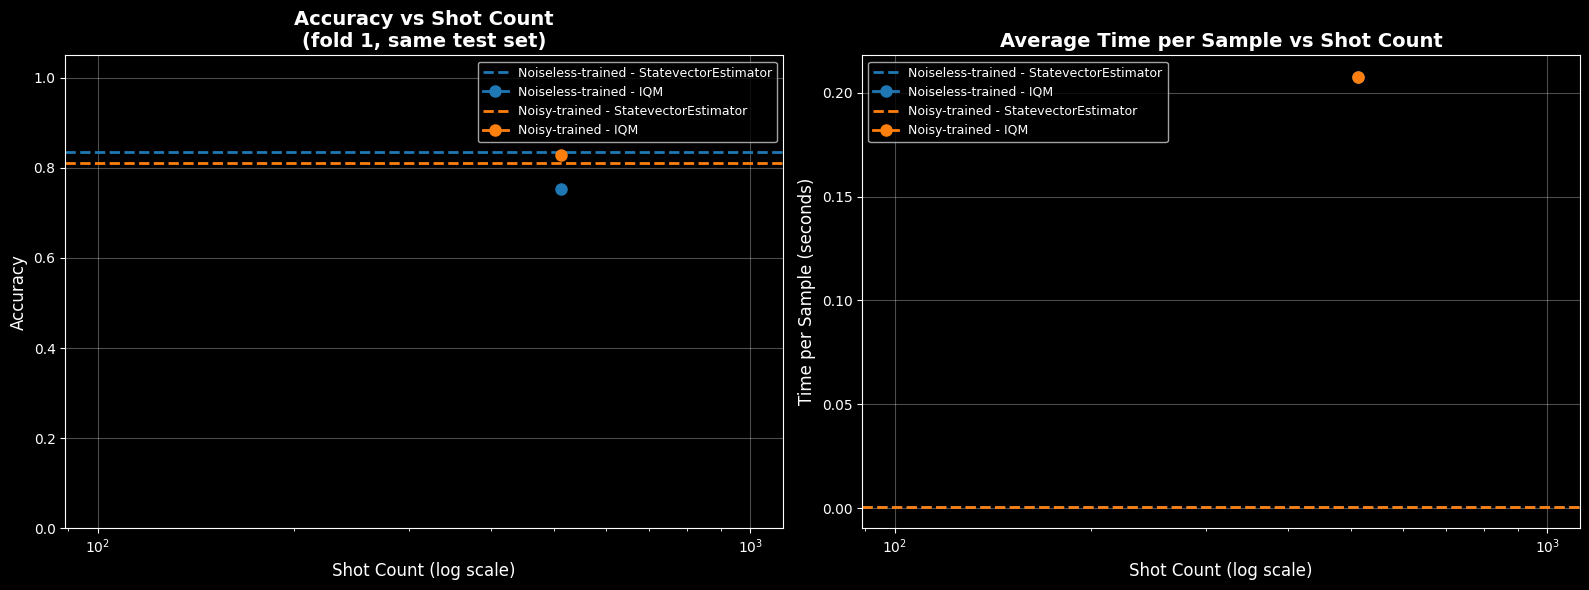

In [23]:
# Visualization: compare both fold-1 models across StatevectorEstimator and IQM
if 'comparison_df' not in globals() or comparison_df.empty:
    print("Run the fold-1 comparison cell first.")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    plotted_hardware = False
    for source in DEFAULT_MODEL_SOURCES:
        color = SOURCE_COLORS.get(source, None)
        label = SOURCE_LABELS.get(source, source)

        sv_rows = comparison_df[
            (comparison_df['source'] == source)
            & (comparison_df['backend'] == 'StatevectorEstimator')
        ]
        hw_rows = comparison_df[
            (comparison_df['source'] == source)
            & (comparison_df['backend'] == 'IQM')
            & (comparison_df['status'] == 'ok')
        ].sort_values('shots')

        if not sv_rows.empty:
            sv_accuracy = sv_rows['accuracy'].iloc[0]
            sv_time = sv_rows['time_per_sample'].iloc[0]
            ax1.axhline(
                y=sv_accuracy,
                color=color,
                linestyle='--',
                linewidth=2,
                label=f'{label} - StatevectorEstimator',
            )
            ax2.axhline(
                y=sv_time,
                color=color,
                linestyle='--',
                linewidth=2,
                label=f'{label} - StatevectorEstimator',
            )

        if not hw_rows.empty:
            plotted_hardware = True
            ax1.plot(
                hw_rows['shots'],
                hw_rows['accuracy'],
                'o-',
                color=color,
                linewidth=2,
                markersize=8,
                label=f'{label} - IQM',
            )
            ax2.plot(
                hw_rows['shots'],
                hw_rows['time_per_sample'],
                'o-',
                color=color,
                linewidth=2,
                markersize=8,
                label=f'{label} - IQM',
            )

    if plotted_hardware:
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    ax1.set_xlabel('Shot Count (log scale)', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.set_title('Accuracy vs Shot Count\n(fold 1, same test set)', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1.05])

    ax2.set_xlabel('Shot Count (log scale)', fontsize=12)
    ax2.set_ylabel('Time per Sample (seconds)', fontsize=12)
    ax2.set_title('Average Time per Sample vs Shot Count', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


## IQM Job Timing Distribution
Inspect the timing breakdown for one evaluated `(model source, shot count)` configuration from the shared comparison results.


In [ ]:
# ========================================================
# IQM Job Timing Distribution Analysis
# ========================================================

print("\n" + "=" * 70)
print("IQM JOB TIMING BREAKDOWN")
print("=" * 70)

if 'timing_estimators' not in globals() or not timing_estimators:
    print("⚠️  No timing data available. Run the fold-1 comparison cell first.")
else:
    available_sources = [s for s in DEFAULT_MODEL_SOURCES if any(key[0] == s for key in timing_estimators)]
    print("\nAvailable timing configurations:")
    for source in available_sources:
        shots_for_source = sorted(shots for (src, shots) in timing_estimators if src == source)
        print(f"  {source} ({SOURCE_LABELS.get(source, source)}): {shots_for_source}")

    default_source = available_sources[-1]
    selected_source = input(
        f"Enter model source to analyze ({', '.join(available_sources)}) [default: {default_source}]: "
    ).strip() or default_source
    if selected_source not in available_sources:
        raise ValueError(f"Invalid source: {selected_source}")

    available_shots = sorted(shots for (src, shots) in timing_estimators if src == selected_source)
    selected_shots = int(
        input(f"Enter shot count to analyze [default: {available_shots[-1]}]: ") or available_shots[-1]
    )
    if (selected_source, selected_shots) not in timing_estimators:
        raise ValueError(f"No timing data for source={selected_source}, shots={selected_shots}")

    selected_model_label = SOURCE_LABELS.get(selected_source, selected_source)
    hw_estimator = timing_estimators[(selected_source, selected_shots)]

    if not hasattr(hw_estimator, 'timestamp_history') or not hw_estimator.timestamp_history:
        print("⚠️  No timestamp history is available for the selected configuration.")
    else:
        qpu_times = []
        compile_times = []
        queue_times = []
        network_times = []

        for t in hw_estimator.timestamp_history:
            ts = t['raw_timestamps']

            if ts.get('execution_started') and ts.get('execution_ended'):
                qpu_times.append((ts['execution_ended'] - ts['execution_started']).total_seconds())

            if ts.get('compilation_started') and ts.get('compilation_ended'):
                compile_times.append((ts['compilation_ended'] - ts['compilation_started']).total_seconds())

            if ts.get('pending_execution') and ts.get('execution_started'):
                queue_times.append((ts['execution_started'] - ts['pending_execution']).total_seconds())

            net_time = 0
            if ts.get('created') and ts.get('pending_compilation'):
                net_time += (ts['pending_compilation'] - ts['created']).total_seconds()
            if ts.get('ready') and ts.get('completed'):
                net_time += (ts['completed'] - ts['ready']).total_seconds()
            network_times.append(net_time)

        total_qpu = sum(qpu_times)
        total_compile = sum(compile_times)
        total_queue = sum(queue_times)
        total_network = sum(network_times)
        total_job = sum(t['job_time_total'] for t in hw_estimator.timestamp_history)
        total_other = total_job - (total_qpu + total_compile + total_queue + total_network)

        print(f"\nModel: {selected_model_label} ({selected_source})")
        print(f"Shots: {selected_shots}")
        print(f"Number of jobs: {len(hw_estimator.timestamp_history)}")
        print(f"Total job time: {total_job:.3f}s")
        print("\nTime Breakdown:")
        print(f"  QPU Execution:    {total_qpu*1000:8.2f} ms  ({100*total_qpu/total_job:5.1f}%)")
        print(f"  Compilation:      {total_compile*1000:8.2f} ms  ({100*total_compile/total_job:5.1f}%)")
        print(f"  Queue (waiting):  {total_queue*1000:8.2f} ms  ({100*total_queue/total_job:5.1f}%)")
        print(f"  Network (I/O):    {total_network*1000:8.2f} ms  ({100*total_network/total_job:5.1f}%)")
        print(f"  Other (overhead): {total_other*1000:8.2f} ms  ({100*total_other/total_job:5.1f}%)")

        labels = ['QPU Execution', 'Compilation', 'Queue', 'Network', 'Other']
        sizes = [total_qpu, total_compile, total_queue, total_network, total_other]
        colors = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4', '#dfe6e9']
        explode = (0.1, 0, 0, 0, 0)

        print("\n" + "=" * 70)


### IQM job timing — visualization
Run after the timing analysis cell above. Uses the currently selected `(model source, shot count)` timing breakdown.


In [ ]:
# Visualization: IQM job time distribution (pie + bar)
if 'sizes' not in globals() or len(sizes) != 5:
    print("Run the IQM timing analysis cell first and ensure timing data is available.")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=90)
    ax1.set_title(
        f'IQM Job Time Distribution\n({selected_model_label}, {selected_shots} shots, '
        f'{len(hw_estimator.timestamp_history)} jobs)',
        fontsize=14,
        fontweight='bold',
    )
    ax2.bar(labels, [s * 1000 for s in sizes], color=colors)
    ax2.set_ylabel('Time (ms)', fontsize=12)
    ax2.set_title('Time Breakdown by Component', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
